**1. Installing and importing libraries**

In [1]:
!pip install tensorflow pandas numpy pillow matplotlib scikit-learn gradio

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import gradio as gr

**2. Loading and inspecting image**

In [3]:
# mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
fer_path = "/content/drive/MyDrive/fer2013.csv"
df = pd.read_csv(fer_path)
df.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [5]:
df["Usage"].value_counts(), df["emotion"].value_counts()

(Usage
 Training       28709
 PublicTest      3589
 PrivateTest     3589
 Name: count, dtype: int64,
 emotion
 3    8989
 6    6198
 4    6077
 2    5121
 0    4953
 5    4002
 1     547
 Name: count, dtype: int64)

**3. Basic image exploration**

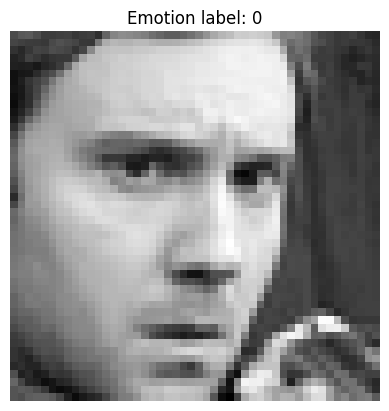

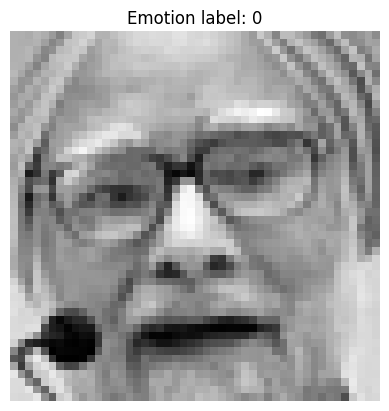

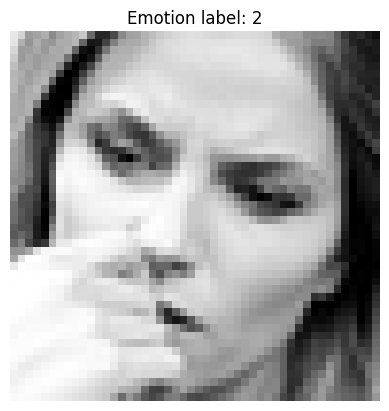

In [6]:
# Taking a few samples from Training set
df_train = df[df["Usage"] == "Training"].copy().reset_index(drop=True)
def plot_sample(idx):
    row = df_train.iloc[idx]
    pixels = row["pixels"]
    emotion = row["emotion"]
    arr = np.fromstring(pixels, dtype=np.uint8, sep=" ")
    arr = arr.reshape(48, 48)
    plt.imshow(arr, cmap="gray")
    plt.title(f"Emotion label: {emotion}")
    plt.axis("off")
    plt.show()
plot_sample(0)
plot_sample(1)
plot_sample(2)

**4. Data cleaning and preprocessing**

In [7]:
# Using only Training data
df_train = df[df["Usage"] == "Training"].copy()
# Subsample to keep it light (we can increase it later)
df_train = df_train.sample(15000, random_state=42).reset_index(drop=True)
len(df_train)

15000

In [8]:
X_list = []
y_list = []
for i, row in df_train.iterrows():
    pixels = row["pixels"]
    emotion = row["emotion"]
    arr = np.fromstring(pixels, dtype=np.uint8, sep=" ")
    arr = arr.reshape(48, 48)
    X_list.append(arr)
    y_list.append(emotion)
X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)
X.shape, y.shape

((15000, 48, 48), (15000,))

In [9]:
# Normalize to [0,1]
X = X / 255.0
# Adding channel dimension: (N, 48, 48, 1)
X = np.expand_dims(X, axis=-1)
num_classes = len(np.unique(y))
y_cat = to_categorical(y, num_classes=num_classes)
X.shape, y_cat.shape, num_classes

((15000, 48, 48, 1), (15000, 7), 7)

**5. Train/Validation split**

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_cat, test_size=0.1, random_state=42, stratify=y
)
X_train.shape, X_val.shape

((13500, 48, 48, 1), (1500, 48, 48, 1))

**6. Building a baseline CNN Model**

In [11]:
def build_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model
model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

**7. Training baseline model**

In [12]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=8,          # start small; increase later
    batch_size=64,
    verbose=1
)

Epoch 1/8
211/211 ━━━━━━━━━━━━━━━━━━━━ 56s 252ms/step - accuracy: 0.2408 - loss: 1.8137 - val_accuracy: 0.2967 - val_loss: 1.7212
Epoch 2/8
211/211 ━━━━━━━━━━━━━━━━━━━━ 75s 221ms/step - accuracy: 0.3184 - loss: 1.7009 - val_accuracy: 0.3853 - val_loss: 1.6065
Epoch 3/8
211/211 ━━━━━━━━━━━━━━━━━━━━ 47s 222ms/step - accuracy: 0.3823 - loss: 1.5859 - val_accuracy: 0.3967 - val_loss: 1.5430
Epoch 4/8
211/211 ━━━━━━━━━━━━━━━━━━━━ 82s 221ms/step - accuracy: 0.4166 - loss: 1.5025 - val_accuracy: 0.4293 - val_loss: 1.4476
Epoch 5/8
211/211 ━━━━━━━━━━━━━━━━━━━━ 47s 221ms/step - accuracy: 0.4499 - loss: 1.4352 - val_accuracy: 0.4547 - val_loss: 1.4040
Epoch 6/8
211/211 ━━━━━━━━━━━━━━━━━━━━ 47s 222ms/step - accuracy: 0.4704 - loss: 1.3887 - val_accuracy: 0.4653 - val_loss: 1.3702
Epoch 7/8
211/211 ━━━━━━━━━━━━━━━━━━━━ 47s 221ms/step - accuracy: 0.4936 - loss: 1.3325 - val_accuracy: 0.4833 - val_loss: 1.3511
Epoch 8/8
211/211 ━━━━━━━━━━━━━━━━━━━━ 47s 223ms/step - accuracy: 0.5077 - loss: 1.2959 - 

**8. Plotting accuracy and loss curves**

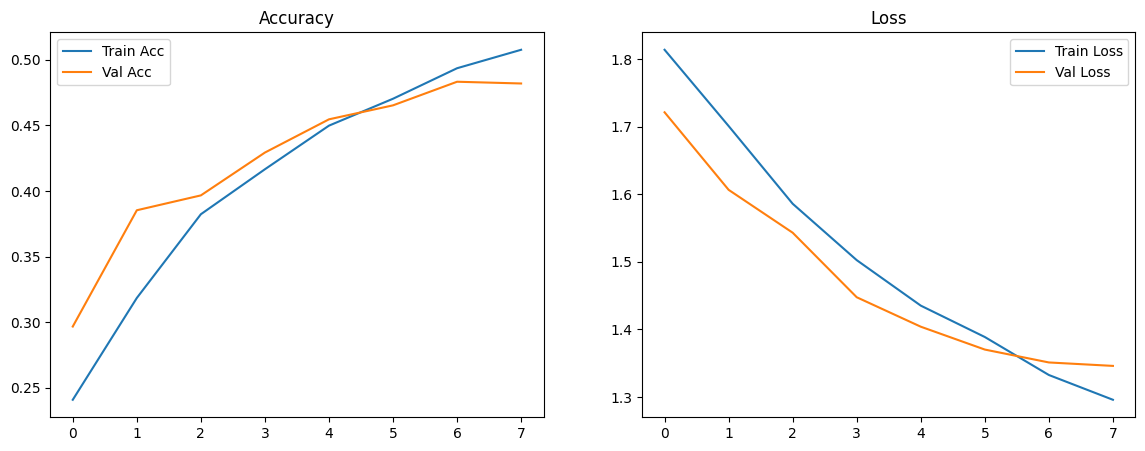

In [13]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()
plt.show()

**9. Fine‑tuning: rebuild with slightly stronger model**

In [14]:
model_ft = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model_ft.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
model_ft.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 44, 44, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,815 (1.66 MB)

 Trainable params: 435,815 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_ft = model_ft.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 123s 568ms/step - accuracy: 0.2410 - loss: 1.8306 - val_accuracy: 0.2500 - val_loss: 1.8171
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 150s 609ms/step - accuracy: 0.2487 - loss: 1.8181 - val_accuracy: 0.2487 - val_loss: 1.8054
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 116s 550ms/step - accuracy: 0.2835 - loss: 1.7530 - val_accuracy: 0.3087 - val_loss: 1.6878
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 120s 568ms/step - accuracy: 0.3353 - loss: 1.6676 - val_accuracy: 0.3720 - val_loss: 1.6041
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 140s 560ms/step - accuracy: 0.3913 - loss: 1.5521 - val_accuracy: 0.4133 - val_loss: 1.5029
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 119s 563ms/step - accuracy: 0.4301 - loss: 1.4716 - val_accuracy: 0.4113 - val_loss: 1.4729
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 137s 542ms/step - accuracy: 0.4604 - loss: 1.4105 - val_accuracy: 0.4507 - val_loss: 1.3984
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 117s 556ms/step - accuracy: 0.4827 -

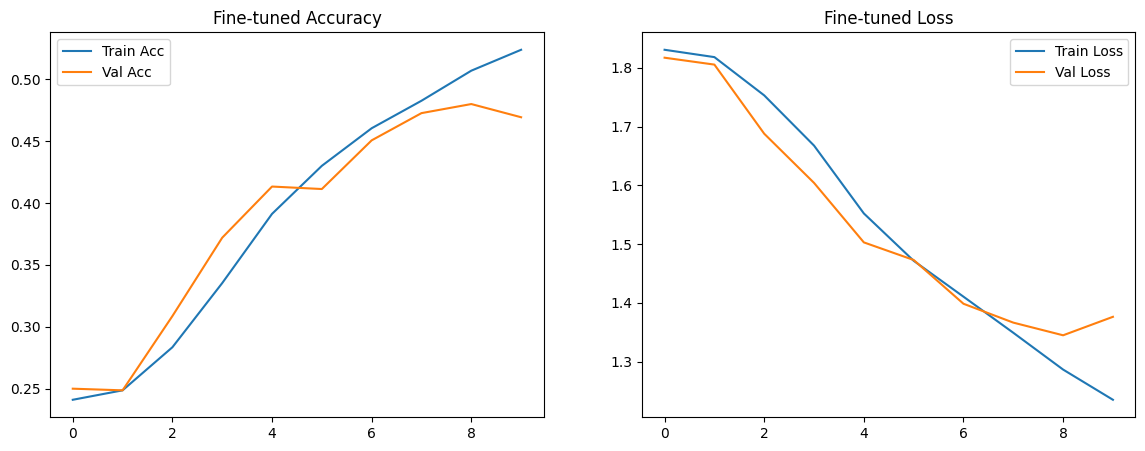

In [16]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history_ft.history['accuracy'], label='Train Acc')
plt.plot(history_ft.history['val_accuracy'], label='Val Acc')
plt.title("Fine-tuned Accuracy")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_ft.history['loss'], label='Train Loss')
plt.plot(history_ft.history['val_loss'], label='Val Loss')
plt.title("Fine-tuned Loss")
plt.legend()
plt.show()

**10. Defining emotion label names**

In [17]:
emotion_names = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

**11. Seeing image, print size, and predict emotion**

In [18]:
def show_and_predict(image):
    # Showing original
    print("Original size:", image.size)
    plt.imshow(image.convert("L"), cmap="gray")
    plt.axis("off")
    plt.show()
    # Resizing to 48x48
    img_resized = image.convert("L").resize((48, 48))
    print("Resized size:", img_resized.size)
    arr = np.array(img_resized, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=-1)
    arr = np.expand_dims(arr, axis=0)
    preds = model_ft.predict(arr)
    idx = int(np.argmax(preds))
    emotion = emotion_names.get(idx, "Unknown")
    print("Predicted emotion:", emotion)
    return emotion

Original size: (800, 1423)


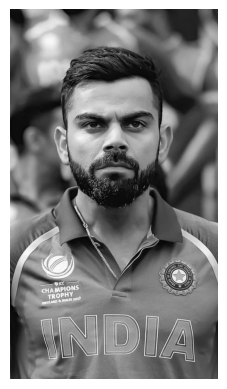

Resized size: (48, 48)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
Predicted emotion: Happy


In [19]:
test_img = Image.open("/content/drive/MyDrive/viratkohli.jpg")
_ = show_and_predict(test_img)

**12. Load movies and inspect**

In [20]:
movies_df = pd.read_csv("/content/drive/MyDrive/movies.csv")
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


**13. Emotion → genre mapping**

In [21]:
def emotion_to_genre(emotion):
    mapping = {
        "Happy": "Comedy",
        "Sad": "Drama",
        "Angry": "Action",
        "Fear": "Horror",
        "Surprise": "Thriller",
        "Disgust": "Mystery",
        "Neutral": "Adventure"
    }
    return mapping.get(emotion, "Adventure")

**14. Recommend movies by genre**

In [22]:
def recommend_movies(genre, top_n=10):
    mask = movies_df["genres"].str.contains(genre, case=False, na=False)
    subset = movies_df[mask].head(top_n)
    return subset["title"].tolist()

**15. Full pipeline function**

In [23]:
def pipeline_from_image(image):
    # image is a PIL Image
    emotion = show_and_predict(image)
    genre = emotion_to_genre(emotion)
    movies = recommend_movies(genre, top_n=10)
    text = f"Detected emotion: {emotion}\nMapped genre: {genre}\n\nRecommended movies:\n"
    for m in movies:
        text += f"- {m}\n"
    return text

**16. Simple app with Gradio**

In [24]:
def gradio_app(image):
    # image is a numpy array; convert to PIL
    pil_img = Image.fromarray(image.astype("uint8"))
    return pipeline_from_image(pil_img)
gr.Interface(
    fn=gradio_app,
    inputs=gr.Image(type="numpy"),
    outputs="text",
    title="Emotion-based Movie Recommender",
    description="Upload a face image. The model predicts your emotion and recommends movies based on it."
).launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2dd043cc1b0d997023.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
